In [62]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de gráficos
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

# Directorio de datos
DATA_DIR = r"C:\Users\camil\Documents\Estudio\DL\Corte1\Dataset\avazu-ctr-prediction"

TRAIN_PATH = os.path.join(DATA_DIR, "train.gz")
TEST_PATH = os.path.join(DATA_DIR, "test.gz")
SUB_PATH = os.path.join(DATA_DIR, "sampleSubmission.gz")

# ==============================
# ⚡ Carga completa del dataset
# ==============================
# Lista de columnas para convertir directamente a categorías (reduce memoria)
cat_cols = [
    'C1', 'banner_pos', 'site_id', 'site_domain', 'site_category',
    'app_id', 'app_domain', 'app_category', 'device_id', 'device_ip',
    'device_model', 'device_type', 'device_conn_type',
    'C14','C15','C16','C17','C18','C19','C20','C21'
]

# Leer CSV completo con compresión gzip
df1 = pd.read_csv(
    TRAIN_PATH,
    compression='gzip',
    dtype={col: 'category' for col in cat_cols},
    low_memory=True
)

# Liberar memoria de variables temporales
gc.collect()

0

In [73]:
df = df1.copy()
# -----------------------------
# 1. Mapeos consolidados
# -----------------------------
df["dct_cat"] = df["device_conn_type"].astype(str)
df["click_cat"] = df["click"].map({0: "No Click", 1: "Click"})

dt_map = {0: "0", 1: "1", 2: "Otros", 3: "Otros", 4: "Otros", 5: "Otros"}
df["dt_cat"] = df["device_type"].map(dt_map)

bp_map = {0: "0", 1: "1", 2: "Otros", 3: "Otros", 4: "Otros", 5: "Otros", 6: "6", 7: "7"}
df["bp_cat"] = df["banner_pos"].map(bp_map)

# -----------------------------
# 2. Fechas y horas
# -----------------------------
df["datetime"] = pd.to_datetime(df["hour"], format="%y%m%d%H")
df["day_week"] = df["datetime"].dt.day_name()
df["hour_day"] = df["hour"] % 100

# -----------------------------
# 3. Franja horaria
# -----------------------------
bins = [0, 6, 12, 18, 24]
labels = ["Madrugada", "Mañana", "Tarde", "Noche"]
df["franja"] = pd.cut(df["hour_day"], bins=bins, labels=labels, right=False).astype(str)

# -----------------------------
# 4. Conteos por grupo
# -----------------------------
count_cols = ['device_ip', 'device_id', 'device_model', 'app_id', 'site_id']
for col in count_cols:
    df[f'{col}_count'] = df.groupby(col)[col].transform('count')

# -----------------------------
# 5. Feature engineering
# -----------------------------
df_fe = df.copy()  # Copiamos después de crear las columnas _count

# Variables derivadas
df_fe['app_per_device'] = df_fe['app_id_count'] / (df_fe['device_id_count'] + 1)
df_fe['site_per_device'] = df_fe['site_id_count'] / (df_fe['device_id_count'] + 1)

C:\Users\camil\AppData\Local\Temp\ipykernel_14940\3706837214.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[f'{col}_count'] = df.groupby(col)[col].transform('count')
C:\Users\camil\AppData\Local\Temp\ipykernel_14940\3706837214.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[f'{col}_count'] = df.groupby(col)[col].transform('count')
C:\Users\camil\AppData\Local\Temp\ipykernel_14940\3706837214.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the fut

In [74]:
import os, time, numpy as np, pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (f1_score, accuracy_score, precision_score, 
                             recall_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve, precision_recall_curve)
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. Muestra representativa
# -----------------------------
df_sample = df_fe.sample(n=250_000, random_state=42)

In [75]:
# -----------------------------
# 6. Selección de variables finales
# -----------------------------
num_vars = [
    "hour_day",
    "device_ip_count",
    "device_id_count",
    "app_id_count",
    "site_id_count",
    "app_per_device",
    "site_per_device"
]

cat_vars = [
    "dct_cat",
    "app_category",
    "site_category"
]

# Variable objetivo
y = df_sample['click'].values

# Codificación de categóricas
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat = ohe.fit_transform(df_sample[cat_vars])

# Combinar numéricas y categóricas
import numpy as np
X_num = df_sample[num_vars].values
X = np.hstack([X_num, X_cat])

print("Shape de X:", X.shape)

Shape de X: (250000, 59)


In [76]:
# -----------------------------
# 3. División train/test
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [80]:
print(X_train.shape)

(200000, 59)


In [78]:
# -----------------------------
# 4. Pipeline y GridSearchCV con sample_weight
# -----------------------------
from sklearn.utils.class_weight import compute_sample_weight
import time

# Calculamos pesos por muestra según la clase
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Definimos pipeline
pipe = make_pipeline(
    StandardScaler(),
    MLPClassifier(random_state=42)
)

# Grid de hiperparámetros
param_grid = {
    'mlpclassifier__hidden_layer_sizes': [(30,), (20,), (64, 32)],
    'mlpclassifier__alpha': [0.00001, 0.000001, 0.0000001],
    'mlpclassifier__activation': ['relu'],
    'mlpclassifier__max_iter': [500, 700]
}

start_time = time.time()

# GridSearchCV
grid = GridSearchCV(pipe, param_grid, cv=3, n_jobs=-1, scoring='f1')
grid.fit(X_train, y_train, **{'mlpclassifier__sample_weight': sample_weights})

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Tiempo de entrenamiento GridSearchCV: {elapsed_time:.2f} segundos")

Tiempo de entrenamiento GridSearchCV: 685.90 segundos


In [83]:
# -----------------------------
# 5. Evaluación
# -----------------------------
y_pred = grid.predict(X_test)
y_proba = grid.predict_proba(X_test)[:, 1]

print("Mejores parámetros encontrados:")
print(grid.best_params_)
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Mejores parámetros encontrados:
{'mlpclassifier__activation': 'relu', 'mlpclassifier__alpha': 1e-07, 'mlpclassifier__hidden_layer_sizes': (64, 32), 'mlpclassifier__max_iter': 500}

Accuracy: 0.6302
Precision: 0.24958661121411033
Recall: 0.5863449087698647
F1-score: 0.35013355827358356
ROC AUC: 0.6629766966105122

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.64      0.74     41505
           1       0.25      0.59      0.35      8495

    accuracy                           0.63     50000
   macro avg       0.57      0.61      0.55     50000
weighted avg       0.78      0.63      0.68     50000



In [71]:
# Predicciones en train y test
y_train_pred = grid.predict(X_train)
y_test_pred = grid.predict(X_test)

from sklearn.metrics import f1_score, accuracy_score

print("Train F1:", f1_score(y_train, y_train_pred))
print("Test F1:", f1_score(y_test, y_test_pred))

Train F1: 0.35065036488116413
Test F1: 0.35032269317983605


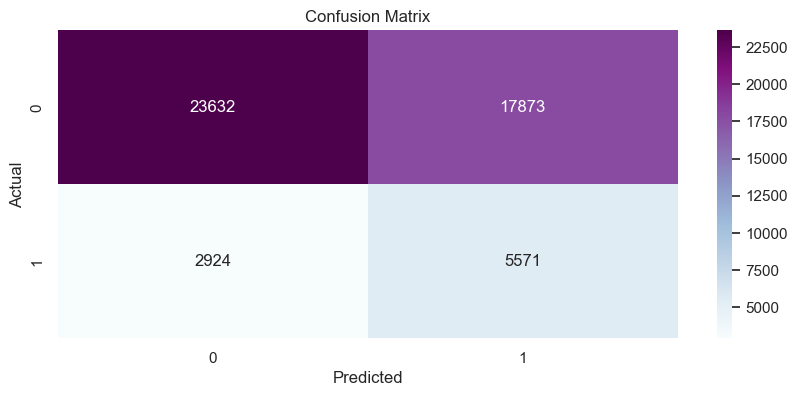

In [30]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='g', cmap="BuPu")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

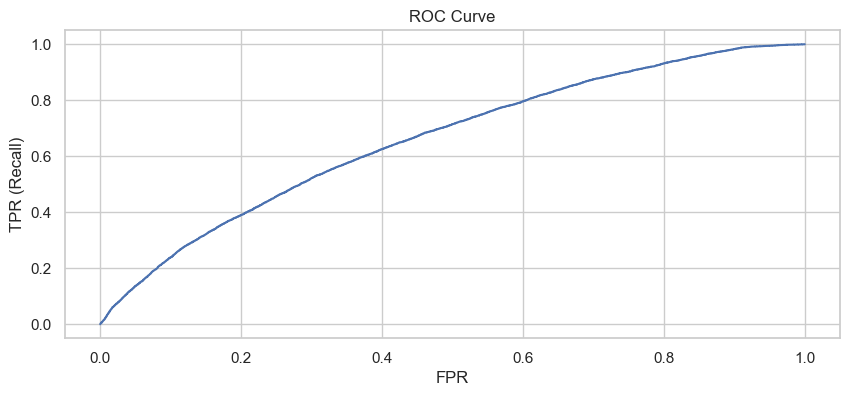

In [19]:
# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr)
plt.xlabel('FPR')
plt.ylabel('TPR (Recall)')
plt.title('ROC Curve')
plt.show()


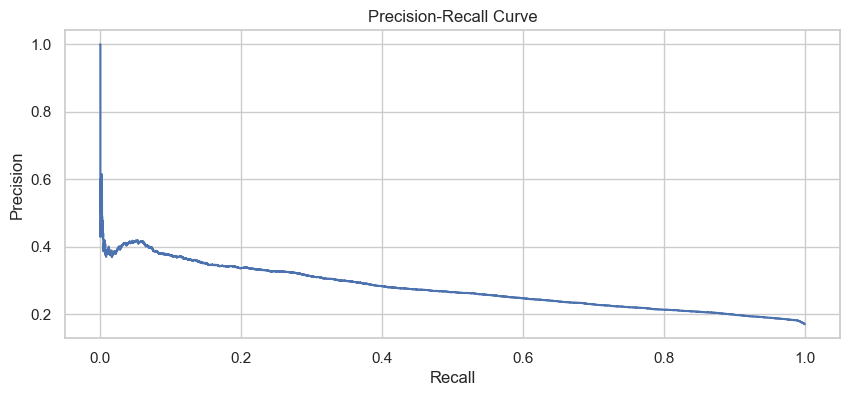

In [20]:
# Curva Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()